#### Dataset = https://catalog.data.gov/dataset/2020-yellow-taxi-trip-data-january-june

## Maximizing Revenue for Taxi Cab Drivers through Payment Type Analysis

### Problem Statement
In the fast - paced taxi booking sector, making the most of revenue is essential for long-term success and driver happiness.
Our Goal is to use data-driven insights to maximize revenue streams for taxi drivers in order to meet this need. 
Our research aims to determine whether payment methods have an impact on fare pricing by focusing on the relationship between payment type and fare amount.

### Objectives
The project's main goal is to run A/B test to examine the relationship between the total fare and the method of payment. We use Python hypothesis testing and descriptive statistics to extract useful information that can help taxi drivers generate more cash. In particular, we want to find out if there is a big difference in the fares for those who pay with credit cards versus those who pay with cash.

### Research Question
Is there relationship between total fare amount and payment type and can we nudge customers towards payment methods that generate higher revenue for drivers, without negatively impacting customer experience?

#### Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as st
import warnings
warnings.filterwarnings('ignore')
import statsmodels.api as sm

#### Loading the Dataset

In [2]:
# Since the dataset is very large, I am taking a small sample out of it
df = pd.read_csv("C:/Users/VIVEK/Downloads/2020_Yellow_Taxi_Trip_Data.csv", nrows = 100000)

In [3]:
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge
0,1.0,01/01/2020 12:28:15 AM,01/01/2020 12:33:03 AM,1.0,1.2,1.0,N,238,239,1.0,6.0,3.0,0.5,1.47,0.0,0.3,11.27,2.5
1,1.0,01/01/2020 12:35:39 AM,01/01/2020 12:43:04 AM,1.0,1.2,1.0,N,239,238,1.0,7.0,3.0,0.5,1.50,0.0,0.3,12.30,2.5
2,1.0,01/01/2020 12:47:41 AM,01/01/2020 12:53:52 AM,1.0,0.6,1.0,N,238,238,1.0,6.0,3.0,0.5,1.00,0.0,0.3,10.80,2.5
3,1.0,01/01/2020 12:55:23 AM,01/01/2020 01:00:14 AM,1.0,0.8,1.0,N,238,151,1.0,5.5,0.5,0.5,1.36,0.0,0.3,8.16,0.0
4,2.0,01/01/2020 12:01:58 AM,01/01/2020 12:04:16 AM,1.0,0.0,1.0,N,193,193,2.0,3.5,0.5,0.5,0.00,0.0,0.3,4.80,0.0


In [5]:
df.tail()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge
99995,2.0,01/01/2020 02:01:08 PM,01/01/2020 02:11:13 PM,1.0,1.89,1.0,N,143,151,1.0,9.5,0.0,0.5,3.20,0.0,0.3,16.00,2.5
99996,2.0,01/01/2020 02:16:00 PM,01/01/2020 02:20:39 PM,1.0,1.15,1.0,N,238,239,1.0,6.0,0.0,0.5,1.86,0.0,0.3,11.16,2.5
99997,2.0,01/01/2020 02:38:25 PM,01/01/2020 02:51:13 PM,1.0,2.81,1.0,N,151,43,1.0,12.0,0.0,0.5,2.30,0.0,0.3,17.60,2.5
99998,2.0,01/01/2020 02:55:54 PM,01/01/2020 03:00:16 PM,1.0,1.17,1.0,N,239,48,1.0,5.5,0.0,0.5,1.30,0.0,0.3,10.10,2.5
99999,2.0,01/01/2020 02:12:36 PM,01/01/2020 02:20:50 PM,1.0,1.25,1.0,N,48,162,1.0,7.0,0.0,0.5,1.03,0.0,0.3,11.33,2.5


#### Exploratory Data Analysis

In [6]:
# Checking the total rows and columns in the dataset
df.shape

(100000, 18)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   VendorID               99808 non-null   float64
 1   tpep_pickup_datetime   100000 non-null  object 
 2   tpep_dropoff_datetime  100000 non-null  object 
 3   passenger_count        99808 non-null   float64
 4   trip_distance          100000 non-null  float64
 5   RatecodeID             99808 non-null   float64
 6   store_and_fwd_flag     99808 non-null   object 
 7   PULocationID           100000 non-null  int64  
 8   DOLocationID           100000 non-null  int64  
 9   payment_type           99808 non-null   float64
 10  fare_amount            100000 non-null  float64
 11  extra                  100000 non-null  float64
 12  mta_tax                100000 non-null  float64
 13  tip_amount             100000 non-null  float64
 14  tolls_amount           100000 non-nul

In [8]:
# Converting the columns to datetime datatype
df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'])
df['tpep_dropoff_datetime'] = pd.to_datetime(df['tpep_dropoff_datetime'])

In [9]:
# Creating a new column to check how much time was utilized to pickup and dropoff the passengers in minutes
df['duration'] = df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']
df.duration.dt.total_seconds()/60

0         4.800000
1         7.416667
2         6.183333
3         4.850000
4         2.300000
           ...    
99995    10.083333
99996     4.650000
99997    12.800000
99998     4.366667
99999     8.233333
Name: duration, Length: 100000, dtype: float64

In [10]:
# Choosing only the required features.
df = df[['passenger_count', 'payment_type', 'fare_amount', 'trip_distance', 'duration']]
df

# or 

# df.drop(['VendorID', 'tpep_pickup_datetime',	'tpep_dropoff_datetime',
#         'RatecodeID', 'store_and_fwd_flag',	'PULocationID',	'DOLocationID',	
#         'extra', 'mta_tax',	'tip_amount', 'tolls_amount', 'improvement_surcharge',
#         'total_amount',	'congestion_surcharge'], axis = 1, inplace = True)

,passenger_count,payment_type,fare_amount,trip_distance,duration
0,1.0,1.0,6.0,1.20,0 days 00:04:48
1,1.0,1.0,7.0,1.20,0 days 00:07:25
2,1.0,1.0,6.0,0.60,0 days 00:06:11
3,1.0,1.0,5.5,0.80,0 days 00:04:51
4,1.0,2.0,3.5,0.00,0 days 00:02:18
...,...,...,...,...,...
99995,1.0,1.0,9.5,1.89,0 days 00:10:05
99996,1.0,1.0,6.0,1.15,0 days 00:04:39
99997,1.0,1.0,12.0,2.81,0 days 00:12:48
99998,1.0,1.0,5.5,1.17,0 days 00:04:22


In [11]:
# Check for missing values
df.isnull().sum()

passenger_count    192
payment_type       192
fare_amount          0
trip_distance        0
duration             0
dtype: int64

In [12]:
print('Missing Data % ', round(192 / df.shape[0] * 100, 2))

Missing Data %  0.19


In [13]:
# as the data has only 0.19% of data-missing, we can simply drop the records with missing values
df = df.dropna()
df

,passenger_count,payment_type,fare_amount,trip_distance,duration
0,1.0,1.0,6.0,1.20,0 days 00:04:48
1,1.0,1.0,7.0,1.20,0 days 00:07:25
2,1.0,1.0,6.0,0.60,0 days 00:06:11
3,1.0,1.0,5.5,0.80,0 days 00:04:51
4,1.0,2.0,3.5,0.00,0 days 00:02:18
...,...,...,...,...,...
99995,1.0,1.0,9.5,1.89,0 days 00:10:05
99996,1.0,1.0,6.0,1.15,0 days 00:04:39
99997,1.0,1.0,12.0,2.81,0 days 00:12:48
99998,1.0,1.0,5.5,1.17,0 days 00:04:22


In [14]:
# changing the passenger count and payment type data to integer as they are present in float
df['passenger_count'] = df['passenger_count'].astype('int64')
df['payment_type'] = df['payment_type'].astype('int64')

In [15]:
# check for the duplcate rows
df[df.duplicated()]

,passenger_count,payment_type,fare_amount,trip_distance,duration
2064,1,2,7.0,0.00,0 days 00:00:00
2451,1,1,52.0,0.00,0 days 00:00:12
2456,2,1,9.5,1.70,0 days 00:13:04
2476,1,1,4.0,0.40,0 days 00:03:05
3358,1,1,6.0,1.20,0 days 00:05:21
...,...,...,...,...,...
99948,1,2,2.5,0.00,0 days 00:00:05
99950,1,2,7.0,1.40,0 days 00:06:13
99962,1,2,5.5,0.90,0 days 00:05:27
99986,1,1,8.0,1.60,0 days 00:08:01


In [16]:
# Removing duplicate rows as they will not contribute in analysis
df = df.drop_duplicates()

In [17]:
# after removing missing values and duplicate rows, now we have this much records left
df.shape

(94840, 5)

In [18]:
# passenger count distribution
df['passenger_count'].value_counts(normalize = True)

passenger_count
1    0.627668
2    0.198893
3    0.058667
5    0.041090
4    0.034743
6    0.022501
0    0.016364
8    0.000053
7    0.000011
9    0.000011
Name: proportion, dtype: float64

In [19]:
# payment type distribution
df['payment_type'].value_counts(normalize = True)

payment_type
1    0.648840
2    0.339477
3    0.006906
4    0.004776
Name: proportion, dtype: float64

In [25]:
# filtering for payment type 1 and 2
df = df[df['payment_type'] < 3]

# filtering for passenger count from 1 to 5.
df = df[(df['passenger_count'] > 0) & (df['passenger_count'] < 6)]

In [26]:
df

,passenger_count,payment_type,fare_amount,trip_distance,duration
0,1,1,6.0,1.20,0 days 00:04:48
1,1,1,7.0,1.20,0 days 00:07:25
2,1,1,6.0,0.60,0 days 00:06:11
3,1,1,5.5,0.80,0 days 00:04:51
4,1,2,3.5,0.00,0 days 00:02:18
...,...,...,...,...,...
99994,2,2,35.0,12.50,0 days 00:26:57
99995,1,1,9.5,1.89,0 days 00:10:05
99996,1,1,6.0,1.15,0 days 00:04:39
99997,1,1,12.0,2.81,0 days 00:12:48


In [27]:
# Replacing the payment type encoded value 1 and 2 to Card and Cash
df['payment_type'].replace([1,2], ['Card', 'Cash'], inplace = True)

In [30]:
# Descriptive Statistics for Data
df.describe().round(2)

,passenger_count,fare_amount,trip_distance,duration
count,90098.00,90098.00,90098.00,90098
mean,1.61,14.02,3.48,0 days 00:17:58.667384403
std,1.05,13.12,3.95,0 days 01:24:40.727554627
min,1.00,-110.00,0.00,0 days 00:00:00
25%,1.00,6.50,1.16,0 days 00:06:14
50%,1.00,10.00,2.10,0 days 00:10:40
75%,2.00,16.50,4.20,0 days 00:17:24
max,5.00,400.00,100.15,0 days 23:59:36


In [34]:
# filtering the records for only positive values
df = df[df['fare_amount'] > 0]
df = df[df['trip_distance'] > 0]
df.shape

(89155, 5)

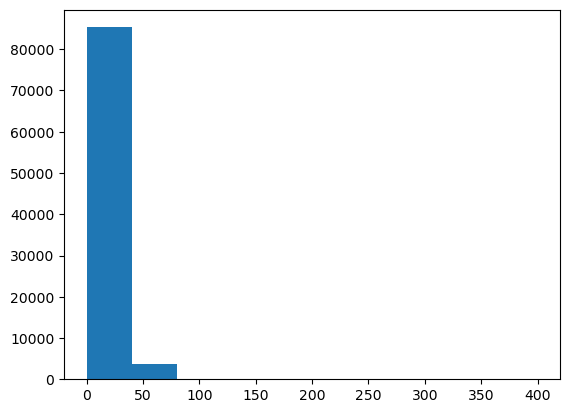

In [39]:
# Check for outliers
plt.hist(df['fare_amount'])
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

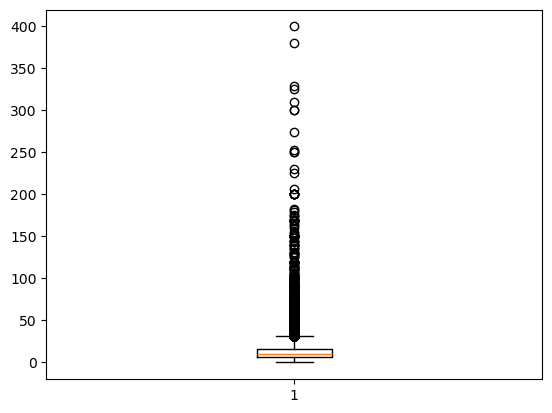

In [40]:
# Check for outliers
plt.boxplot(df['fare_amount'])
plt.show

In [41]:
# removing outliers using interquartile range for the numerical variables
for col in ['fare_amount', 'trip_distance', 'duration']:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    IQR = q3 - q1

    # Defining lower and upper bounds for outliers
    lower_bound = q1 - 1.5 * IQR
    upper_bound = q3 + 1.5 * IQR

    # filtering out outliers
    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

In [44]:
df.head()

,passenger_count,payment_type,fare_amount,trip_distance,duration
0,1,Card,6.0,1.20,0 days 00:04:48
1,1,Card,7.0,1.20,0 days 00:07:25
2,1,Card,6.0,0.60,0 days 00:06:11
3,1,Card,5.5,0.80,0 days 00:04:51
5,1,Cash,2.5,0.03,0 days 00:00:53


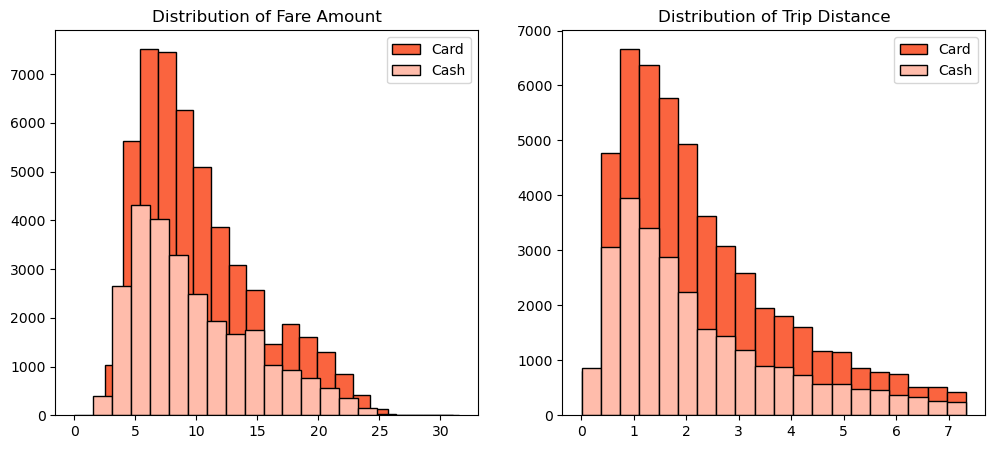

In [49]:
plt.figure(figsize = (12, 5))
plt.subplot(1,2,1)
plt.hist(df[df['payment_type'] == 'Card']['fare_amount'], histtype = 'barstacked', bins = 20,
        edgecolor = 'k', color = '#FA643F', label = 'Card')
plt.hist(df[df['payment_type'] == 'Cash']['fare_amount'], histtype = 'barstacked', bins = 20,
        edgecolor = 'k', color = '#FFBCAB', label = 'Cash')
plt.title('Distribution of Fare Amount')
plt.legend()

plt.subplot(1,2,2)
plt.hist(df[df['payment_type'] == 'Card']['trip_distance'], histtype = 'barstacked', bins = 20,
        edgecolor = 'k', color = '#FA643F', label = 'Card')
plt.hist(df[df['payment_type'] == 'Cash']['trip_distance'], histtype = 'barstacked', bins = 20,
        edgecolor = 'k', color = '#FFBCAB', label = 'Cash')
plt.title('Distribution of Trip Distance')
plt.legend()
plt.show()

In [50]:
# Calculating the mean and standard deviation group by on payment type
df.groupby('payment_type').agg({'fare_amount' : ['mean', 'std'], 'trip_distance' : ['mean', 'std']})

fare_amount           trip_distance          
                    mean       std          mean       std
payment_type                                              
Card           10.199834  4.832174      2.335343  1.580520
Cash            9.826232  4.908142      2.224048  1.634934

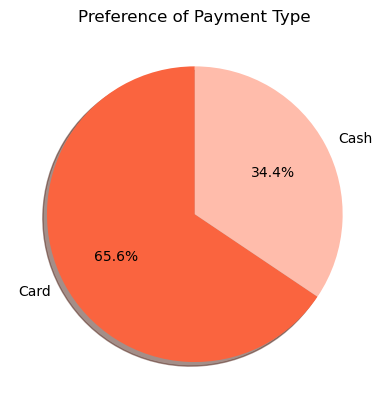

In [51]:
plt.title('Preference of Payment Type')
plt.pie(df['payment_type'].value_counts(normalize = True), labels = df['payment_type'].value_counts().index,
       startangle = 90, shadow = True, autopct = '%1.1f%%', colors = ['#FA643F', '#FFBCAB'])
plt.show()

In [53]:
# calculating the total passenger count distribution based on the different payment type
passenger_count = df.groupby(['payment_type', 'passenger_count'])[['passenger_count']].count()

# renaming the passenger_cout to count to reset the index
passenger_count.rename(columns = {'passenger_count' : 'count'}, inplace = True)
passenger_count.reset_index(inplace = True)

In [56]:
# Calculating the percentage of each of the passenger count
passenger_count['Percentage'] = (passenger_count['count'] / passenger_count['count'].sum()) * 100

In [61]:
passenger_count

,payment_type,passenger_count,count,Percentage
0,Card,1,32734,42.763828
1,Card,2,10635,13.893606
2,Card,3,2962,3.869569
3,Card,4,1591,2.078489
4,Card,5,2273,2.969456
5,Cash,1,17325,22.633449
6,Cash,2,5172,6.756721
7,Cash,3,1702,2.223500
8,Cash,4,1096,1.431819
9,Cash,5,1056,1.379563


In [62]:
# creating a new empty dataframe to store the distribution of each payment type (useful for the visualization)
df1 = pd.DataFrame(columns = ['payment_type', 1,2,3,4,5])
df1['payment_type'] = ['Card', 'Cash']
df1.iloc[0,1 : ] = passenger_count.iloc[0:5, -1]
df1.iloc[1,1 : ] = passenger_count.iloc[5:, -1]
df1

,payment_type,1,2,3,4,5
0,Card,42.763828,13.893606,3.869569,2.078489,2.969456
1,Cash,22.633449,6.756721,2.2235,1.431819,1.379563


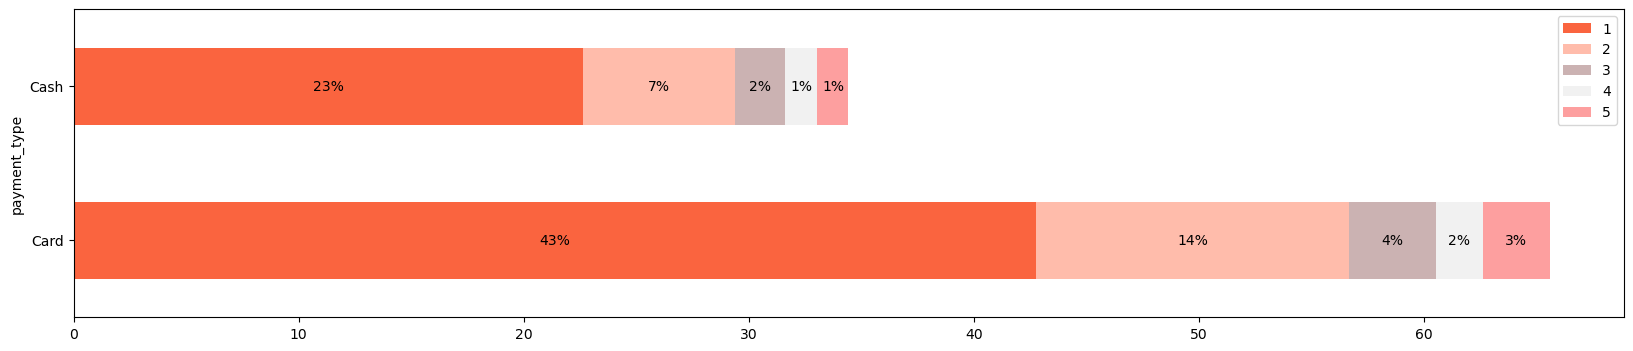

In [70]:
ax = df1.plot(x = 'payment_type', kind = 'barh', stacked = True, color = ['#FA643F', '#FFBCAB', '#CBB2B2', 
                                                                    '#F1F1F1', '#FD9F9F'], figsize=(20, 4))
# Add percentage text
for p in ax.patches:
    width = p.get_width()
    height = p.get_height()
    x, y = p.get_xy()
    ax.text(x + width / 2,
           y + height / 2,
           '{:.0f}%'.format(width),
           horizontalalignment = 'center',
           verticalalignment = 'center')

plt.show()

### Hypothesis Testing

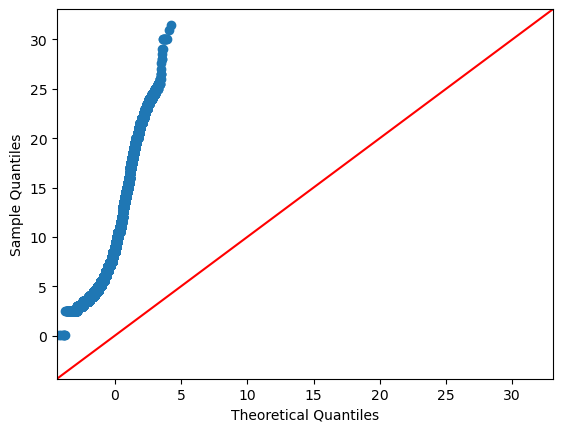

In [71]:
# Creating Q-Q plot with 45 degree line added to plot
sm.qqplot(df['fare_amount'], line = '45')
plt.show()

The data values clearly do not follow the red 45-degree line, which is an indication that they do not follow a normal distribution. So, the z distribution will not be good for this. That's why we will use T-test.


Given that the T-test can be applied to both small and large samples and does not require the population standard deviation, it is a more universally applicable approach for hypothesis testing in many practical research scenarios, including analysis of taxi trip data.


In the anlaysis of NYC Yellow Trip Records, where we're likely dealing with an unknown population standard deviation and potentially  large datasets, the T-test offers a more appropriate and flexible method for comparing means between two groups (e.g., fare amounts by payment type). It provides a reliable way to infer about the population, accomodating the uncertainty that comes with estimating population parameters from sample data.

<b>Null Hypothesis:</b> There is no difference in average fare between customers who use credit cards and customers who use cash.

<b>Alternative Hypothesis:</b> There is a difference in average fare between customers who use credit cards and customers who use cash.

In [72]:
# sample 1
card_sample = df[df['payment_type'] == 'Card']['fare_amount']
# sample 2
cash_sample = df[df['payment_type'] == 'Cash']['fare_amount']

In [73]:
# performing t test on both the different sample
t_stats, p_value = st.ttest_ind(a = card_sample, b = cash_sample, equal_var = False)
print('T Statistic: ', t_stats, '\np-value: ', p_value)

T Statistic:  10.059284220574412 
p-value:  8.783442371491058e-24


In [74]:
# comparing the p value with the significance of 5% or 0.05
if p_value < 0.05:
    print('\nReject the Null Hypothesis')
else:
    print('\nAccept the Null Hypothesis')


Reject the Null Hypothesis


Since the p-value is significantly smaller than the significance level of 5%, we will reject the null hypothesis.


We can conclude that there is a statistically significant difference in the average fare amount between customers who use credit cards and customers who use cash.


The key business insight is that <b>encouraging customers to pay with credit cards can generate more revenue</b> for taxi cab drivers.